Generating TPC-H data (SF=0.1)...
TPC-H data ready.

EXPERIMENT 1: DuckDB vs SQLite

[1.1] SELECT + WHERE
DuckDB : 0.09521s
SQLite : 0.12553s
Speedup: 1.32x

[1.2] Aggregation
DuckDB : 0.04131s
SQLite : 0.31512s
Speedup: 7.63x

[1.3] LIKE
DuckDB : 0.01085s
SQLite : 0.00899s
Speedup: 0.83x


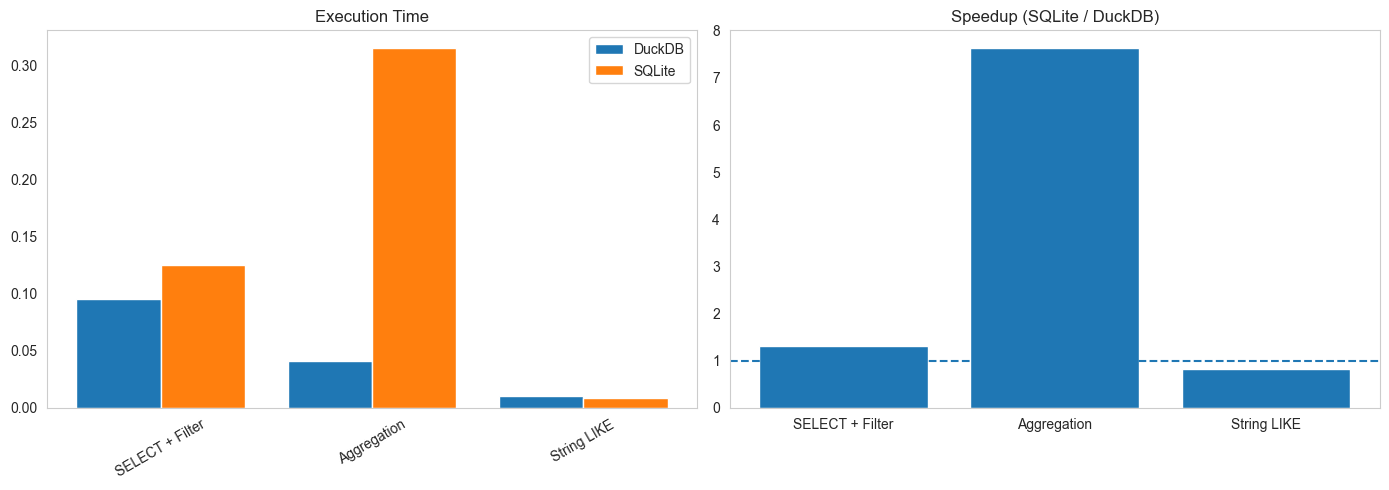

In [ ]:
"""
DuckDB Vectorized Execution - Experiment 1 (Functional Version)
TPC-H Benchmark | DuckDB vs SQLite
"""

import duckdb
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# 1. Setup DuckDB + TPC-H
# -----------------------------
def init_duckdb(scale_factor=0.1):
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H data (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    
    print("TPC-H data ready.\n")
    return con


# -----------------------------
# 2. Prepare SAME data for both engines
# -----------------------------
def prepare_benchmark_data(con, lineitem_rows=1000_000, customer_rows=100_000):
    
    # Sample from DuckDB
    lineitem_df = con.execute(f"""
        SELECT
            l_orderkey,
            l_partkey,
            l_quantity,
            l_extendedprice,
            l_returnflag,
            l_shipdate,
            l_discount
        FROM lineitem
        LIMIT {lineitem_rows}
    """).df()

    customer_df = con.execute(f"""
        SELECT c_name, c_address
        FROM customer
        LIMIT {customer_rows}
    """).df()

    # Convert date for SQLite
    lineitem_df["l_shipdate"] = pd.to_datetime(
        lineitem_df["l_shipdate"]
    ).dt.strftime("%Y-%m-%d")

    # Register in DuckDB
    con.register("bench_lineitem", lineitem_df)
    con.register("bench_customer", customer_df)

    # Load into SQLite
    sqlite_con = sqlite3.connect(":memory:")
    lineitem_df.to_sql("bench_lineitem", sqlite_con, index=False)
    customer_df.to_sql("bench_customer", sqlite_con, index=False)

    return sqlite_con


# -----------------------------
# 3. Timing functions
# -----------------------------
def time_duckdb(con, query):
    start = time.perf_counter()
    result = con.execute(query).fetchall()
    return time.perf_counter() - start, result


def time_sqlite(sqlite_con, query):
    start = time.perf_counter()
    result = sqlite_con.execute(query).fetchall()
    return time.perf_counter() - start, result


# -----------------------------
# 4. Experiment 1
# -----------------------------
def experiment_1(con, sqlite_con):

    print("="*80)
    print("EXPERIMENT 1: DuckDB vs SQLite")
    print("="*80)

    results = {
        "operation": [],
        "duckdb_time": [],
        "sqlite_time": [],
        "speedup": []
    }

    # -------------------------
    # 1. SELECT + FILTER
    # -------------------------
    print("\n[1.1] SELECT + WHERE")

    query = """
        SELECT l_orderkey, l_partkey, l_quantity, l_extendedprice
        FROM bench_lineitem
        WHERE l_quantity > 30 AND l_discount < 0.05
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("SELECT + Filter")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # -------------------------
    # 2. AGGREGATION
    # -------------------------
    print("\n[1.2] Aggregation")

    query = """
        SELECT
            l_returnflag,
            COUNT(*),
            SUM(l_quantity),
            AVG(l_extendedprice)
        FROM bench_lineitem
        WHERE l_shipdate <= '1998-09-01'
        GROUP BY l_returnflag
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("Aggregation")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # -------------------------
    # 3. STRING LIKE
    # -------------------------
    print("\n[1.3] LIKE")

    query = """
        SELECT c_name, c_address
        FROM bench_customer
        WHERE c_name LIKE 'Customer%000%'
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("String LIKE")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    return results



def plot_results(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(df))

   
    axes[0].bar(x - 0.2, df["duckdb_time"], 0.4, label="DuckDB")
    axes[0].bar(x + 0.2, df["sqlite_time"], 0.4, label="SQLite")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["operation"], rotation=30)
    axes[0].set_title("Execution Time")
    axes[0].legend()
    axes[0].grid()

    # Speedup
    axes[1].bar(df["operation"], df["speedup"])
    axes[1].set_title("Speedup (SQLite / DuckDB)")
    axes[1].axhline(y=1, linestyle="--")
    axes[1].grid()

    plt.tight_layout()
    plt.show()


# -----------------------------
# 6. RUN (Notebook cell)
# -----------------------------
con = init_duckdb(scale_factor=0.1)
sqlite_con = prepare_benchmark_data(con)

results = experiment_1(con, sqlite_con)
plot_results(results)